# **Цель работы**
1. Изучить проблему высокой размерности данных и её влияние на анализ.
2. Освоить методы линейного и нелинейного снижения размерности.
3. Научиться выявлять скрытую структуру данных и интерпретировать
результаты преобразований.
4. Научиться интерпретировать новые признаки, полученные после
преобразования пространства признаков.

# **Задание 1. Геометрия данных в пространстве признаков**
Используйте датасет с числовыми признаками.
1. Определите:
- число объектов
- число признаков.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
upl = files.upload()
# Загрузка данных
df = pd.read_csv('toyota.csv')  # Путь к вашему файлу

# Выводим первые строки и информацию о данных
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())

Saving toyota.csv to toyota.csv
Первые 5 строк:
   model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   GT86  2016  16000       Manual    24089   Petrol  265  36.2         2.0
1   GT86  2017  15995       Manual    18615   Petrol  145  36.2         2.0
2   GT86  2015  13998       Manual    27469   Petrol  265  36.2         2.0
3   GT86  2017  18998       Manual    14736   Petrol  150  36.2         2.0
4   GT86  2017  17498       Manual    36284   Petrol  145  36.2         2.0

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           673

In [2]:
# Выбираем только числовые признаки
numeric_df = df.select_dtypes(include=[np.number])

# Определяем число объектов и число признаков
n_samples, n_features = numeric_df.shape
print(f"Число объектов: {n_samples}")
print(f"Число числовых признаков: {n_features}")
print(f"Список числовых признаков: {list(numeric_df.columns)}")

Число объектов: 6738
Число числовых признаков: 6
Список числовых признаков: ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']


2. Постройте:
* гистограммы распределения признаков;
* матрицу корреляций признаков.

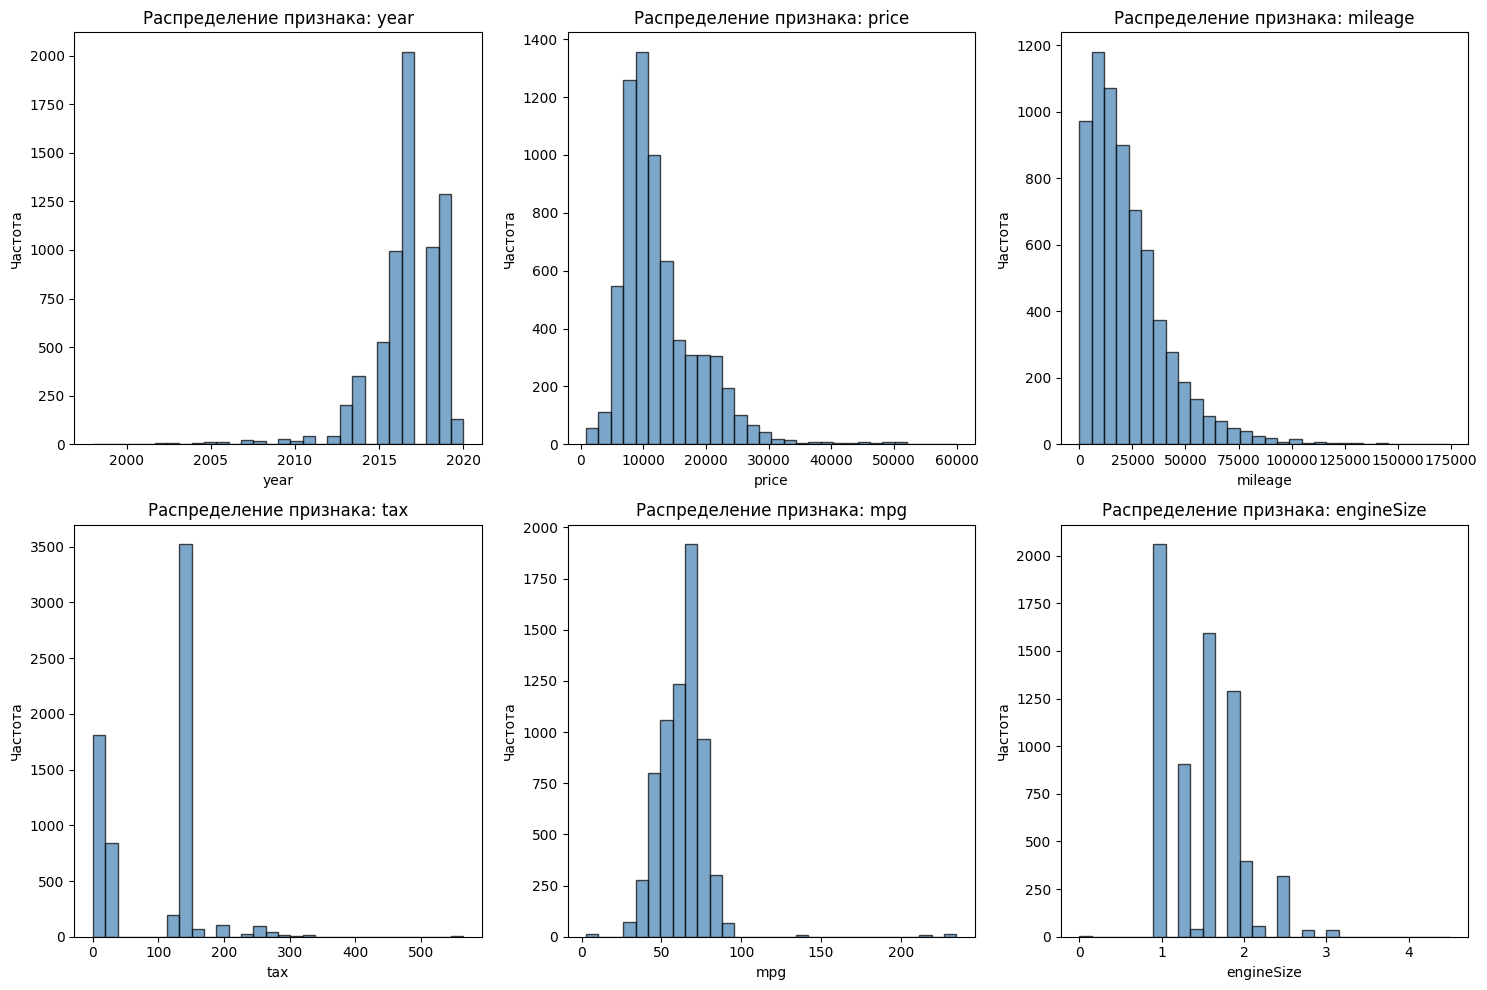

In [3]:
# Настройка размера графиков
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

# Строим гистограмму для каждого числового признака
for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col], bins=30, edgecolor='k', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Распределение признака: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

# Убираем лишние пустые подграфики
for i in range(len(numeric_df.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

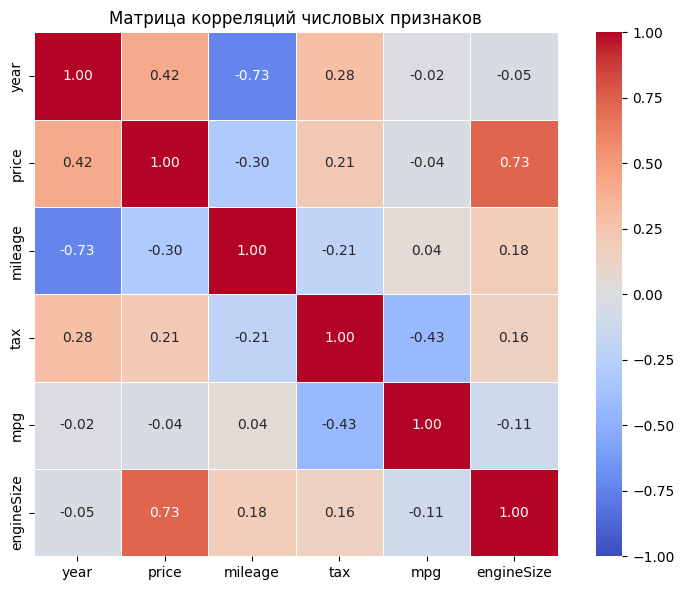

In [4]:
# Вычисляем матрицу корреляций
corr_matrix = numeric_df.corr()

# Строим тепловую карту
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()


3. Ответьте на вопросы:
* Есть ли сильно коррелированные признаки?
* Можно ли предположить, что часть признаков содержит избыточную
информацию?

1. Есть ли сильно коррелированные признаки?

Да. Две пары признаков имеют сильную корреляцию (|r| ≥ 0.7):

`mileage` и `year`: r = -0.73 (сильная отрицательная связь)

`price` и `engineSize`: r = +0.73 (сильная положительная связь)

2. Можно ли предположить, что часть признаков содержит избыточную информацию?

Да. Поскольку `mileage` и `year` сильно связаны (чем новее авто, тем меньше пробег), а `price` и `engineSize` также сильно связаны (чем больше двигатель, тем выше цена), эти пары признаков дублируют друг друга. Это означает, что часть информации избыточна, и размерность данных можно сократить без существенных потерь.

# **Задание 2. Реализация PCA**
Реализуйте алгоритм PCA с нуля, используя только библиотеку NumPy.
Алгоритм должен включать:
1. Стандартизацию данных.
2. Вычисление ковариационной матрицы.
3. Нахождение собственных значений и собственных векторов.
4. Сортировку компонент по убыванию собственных значений.
5. Проекцию данных на первые k компонент.

Сравните результат с реализацией:
sklearn.decomposition.PCA



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

df = pd.read_csv('toyota.csv')
X = df.select_dtypes(include=[np.number]).dropna().values

# 1. PCA с нуля
def my_pca(X, k):
    # 1. Стандартизация
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
# какой диапазон получаем?  примерно от -2.5 до +3.8
    # print(X_scaled.min())
    # print(X_scaled.max())

    # 2. Ковариационная матрица
    cov = np.cov(X_scaled.T)

    # 3. Собственные значения и векторы
    eig_vals, eig_vecs = np.linalg.eig(cov)

    # 4. Сортировка по убыванию
    idx = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[idx]
    eig_vecs = eig_vecs[:, idx]

    # 5. Проекция на первые k компонент
    X_proj = X_scaled @ eig_vecs[:, :k]

    return X_proj, eig_vals

# Применяем
X_pca, eig_vals = my_pca(X, k=2)

# Доля объяснённой дисперсии
explained_ratio = eig_vals / eig_vals.sum()
cumulative = np.cumsum(explained_ratio)

# 2. Сравнение с sklearn
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
sklearn_pca = SklearnPCA()
sklearn_pca.fit(X_scaled)

print("Сравнение доли объяснённой дисперсии:")
print(f"NumPy PCA: {explained_ratio[:3]}")
print(f"sklearn PCA: {sklearn_pca.explained_variance_ratio_[:3]}")



Сравнение доли объяснённой дисперсии:
NumPy PCA: [0.37514814 0.26209482 0.21120397]
sklearn PCA: [0.37514814 0.26209482 0.21120397]


# 2.1 Исследование
Постройте график:
- доля объяснённой дисперсии
- накопленная объяснённая дисперсия


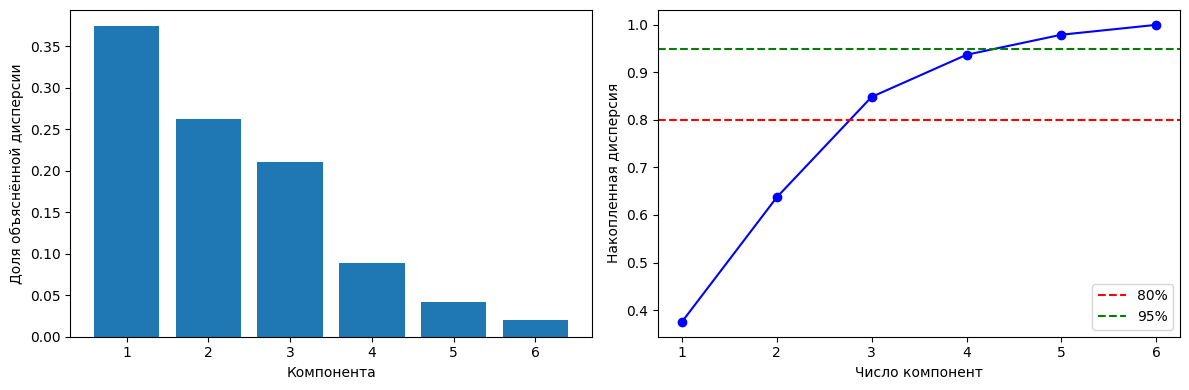

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Доля дисперсии
axes[0].bar(range(1, len(explained_ratio)+1), explained_ratio)
axes[0].set_xlabel('Компонента')
axes[0].set_ylabel('Доля объяснённой дисперсии')

# Накопленная дисперсия
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-')
axes[1].axhline(0.8, color='r', linestyle='--', label='80%')
axes[1].axhline(0.95, color='g', linestyle='--', label='95%')
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Накопленная дисперсия')
axes[1].legend()
plt.tight_layout()
plt.show()



# Ответьте:
1. Сколько компонент объясняют 80% дисперсии?
2. Сколько компонент объясняют 95% дисперсии?


1. Компонент для 80% дисперсии: 3
2. Компонент для 95% дисперсии: 5

# **Задание 3. Интерпретация главных компонент**
Рассмотрите первые три главные компоненты.
1. Определите коэффициенты признаков в каждой компоненте.
2. Найдите признаки с наибольшим вкладом.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('toyota.csv')
X = df.select_dtypes(include=[np.number]).dropna().values
feature_names = df.select_dtypes(include=[np.number]).columns.tolist()

# СТАНДАРТИЗАЦИЯ И PCA
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
cov = np.cov(X_scaled.T)
eig_vals, eig_vecs = np.linalg.eigh(cov)
idx = np.argsort(eig_vals)[::-1]
eig_vecs = eig_vecs[:, idx]

# 1. КОЭФФИЦИЕНТЫ ПРИЗНАКОВ (2 знака после запятой)
components = eig_vecs[:, :3]
coef_df = pd.DataFrame(components, index=feature_names, columns=['PC1', 'PC2', 'PC3'])
print("Коэффициенты признаков в первых трёх компонентах:")
print(coef_df.round(2))

# 2. ПРИЗНАКИ С НАИБОЛЬШИМ ВКЛАДОМ (2 знака после запятой)
print("\nПризнаки с наибольшим вкладом (по модулю коэффициента):")
for pc in ['PC1', 'PC2', 'PC3']:
    top = coef_df[pc].abs().sort_values(ascending=False)
    print(f"\n{pc}: {top.index[0]} ({top.values[0]:.2f}), {top.index[1]} ({top.values[1]:.2f})")

Коэффициенты признаков в первых трёх компонентах:
             PC1   PC2   PC3
year       -0.52  0.39 -0.15
price      -0.52 -0.35 -0.33
mileage     0.45 -0.49  0.11
tax        -0.38 -0.06  0.55
mpg         0.20  0.14 -0.72
engineSize -0.28 -0.68 -0.19

Признаки с наибольшим вкладом (по модулю коэффициента):

PC1: year (0.52), price (0.52)

PC2: engineSize (0.68), mileage (0.49)

PC3: mpg (0.72), tax (0.55)


# Ответьте:
1. Какие признаки больше всего влияют на первую компоненту?
2. Можно ли интерпретировать первую компоненту как некоторую
комбинацию исходных признаков?
3. Есть ли признаки, которые практически не влияют на первые компоне

**1. Какие признаки больше всего влияют на первую компоненту?**

`year` и `price` (0.52). Также высокий вклад у `mileage` (0.45) и `tax` (0.38)

**2. Можно ли интерпретировать первую компоненту как некоторую комбинацию исходных признаков?**

Да. Первая компонента — это взвешенная сумма всех признаков. Она отражает «ВОЗРАСТ И ЦЕНУ» автомобиля: высокие значения PC1 соответствуют старым машинам с большим пробегом и низкой ценой.

**3. Есть ли признаки, которые практически не влияют на первые компоненты?**

Нет. Все признаки имеют заметный вклад хотя бы в одну из первых трёх компонент:

`mpg` слабо влияет на PC1 и PC2, но сильно на PC3 (0.72)

`tax` слабо на PC1 и PC2, но на PC3 даёт 0.55

Таким образом, все 6 признаков важны для описания данных в пространстве главных компонент.

# **Задание 4. Визуализация данных**
Постройте:
1. визуализацию по двум исходным признакам;
2. визуализацию по двум главным компонентам.



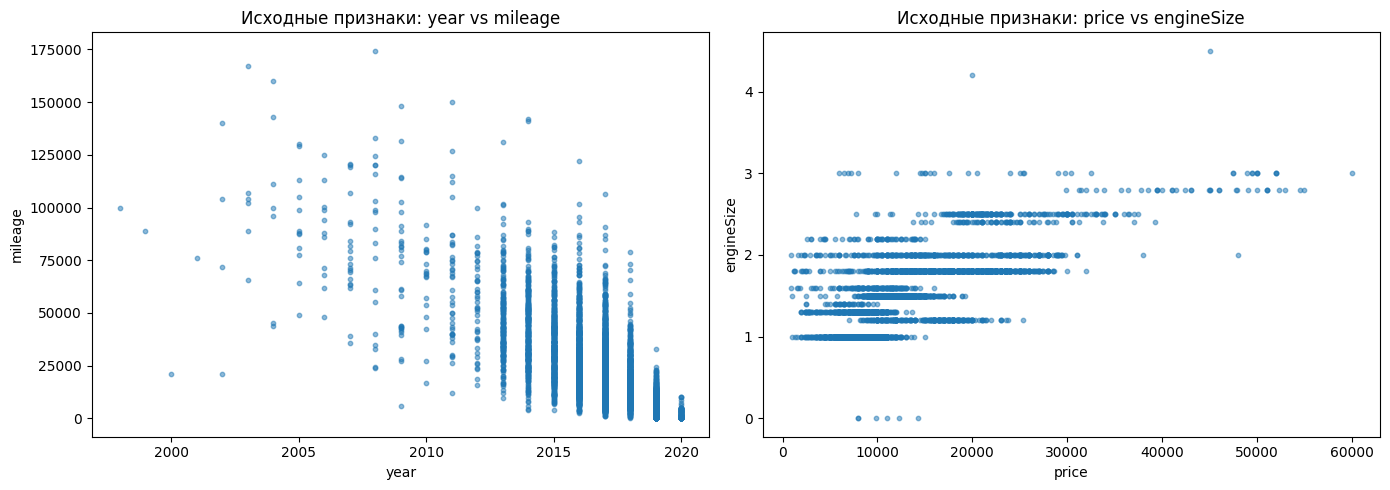

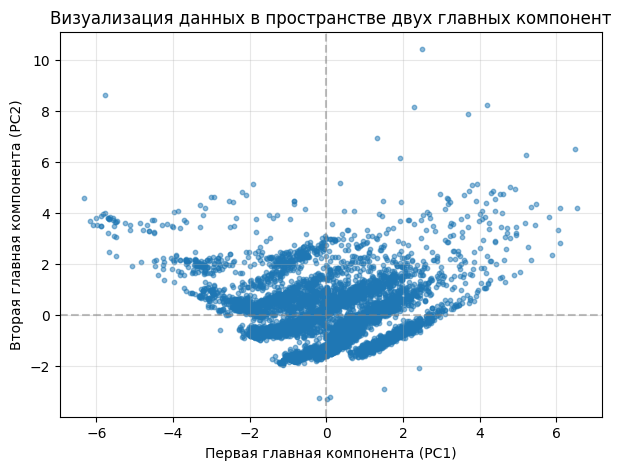

In [ ]:

# ========== 1. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ИСХОДНЫМ ПРИЗНАКАМ ==========
# По матрице корреляций: price и engineSize (0.73) ИЛИ year и mileage (-0.73)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Вариант 1: year vs mileage
axes[0].scatter(X[:, 0], X[:, 2], alpha=0.5, s=10)
axes[0].set_xlabel('year')
axes[0].set_ylabel('mileage')
axes[0].set_title('Исходные признаки: year vs mileage')

# Вариант 2: price vs engineSize
axes[1].scatter(X[:, 1], X[:, 5], alpha=0.5, s=10)
axes[1].set_xlabel('price')
axes[1].set_ylabel('engineSize')
axes[1].set_title('Исходные признаки: price vs engineSize')

plt.tight_layout()
plt.show()

# ========== 2. ВИЗУАЛИЗАЦИЯ ПО ДВУМ ГЛАВНЫМ КОМПОНЕНТАМ ==========
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=10)
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title('Визуализация данных в пространстве двух главных компонент')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(alpha=0.3)
plt.show()

# Сравните:
* структуру распределения объектов;
* наличие групп или закономерностей.



На исходных графиках (например, `year vs mileage` или `price vs engineSize`) точки сильно вытянуты вдоль одной диагонали, потому что признаки коррелируют между собой. Это приводит к тому, что структура данных плохо видна, а многие точки накладываются друг на друга.


В пространстве главных компонент ситуация иная. Первая компонента (PC1) направлена вдоль оси максимальной дисперсии, а вторая компонента (PC2) ортогональна ей и показывает следующее по важности направление. Поскольку компоненты не коррелируют, данные распределяются по осям более равномерно, без диагонального вытягивания.

# Ответьте:
1. Улучшилась ли визуализация после PCA?
2. Почему в пространстве главных компонент структура может быть заметнее?

1. Улучшилась ли визуализация после PCA?

Да, улучшилась. На исходных графиках точки скучены вдоль диагонали из-за корреляции признаков. После PCA оси становятся независимыми, точки распределяются равномерно, что позволяет лучше увидеть кластеры, выбросы и общую структуру данных.

2. Почему в пространстве главных компонент структура может быть заметнее?

По двум причинам:

* Ортогональность компонент — главные компоненты не коррелируют друг с другом. Это устраняет диагональное вытягивание, которое мешало на исходных графиках.

* Максимизация дисперсии — каждая компонента показывает направление наибольшей вариации данных. Первые две компоненты «забирают» максимум информации, позволяя увидеть данные с самых информативных ракурсов.



# **Задание 5. Нелинейные методы снижения размерности**
Используйте два метода:
- t-SNE
- UMAP

Постройте двумерные проекции данных.


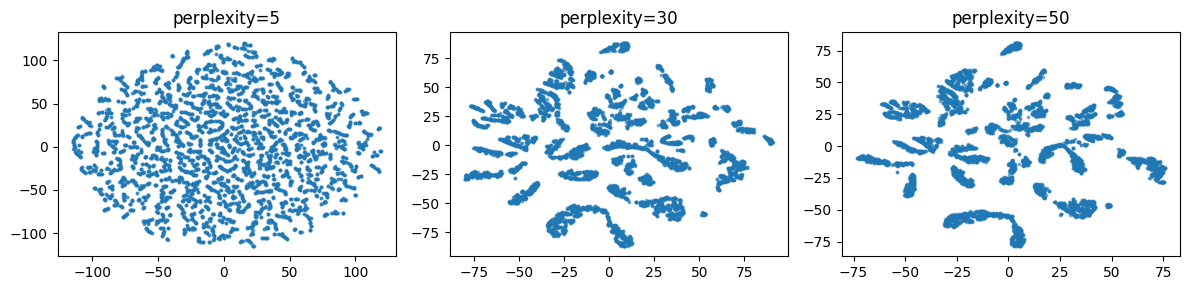

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


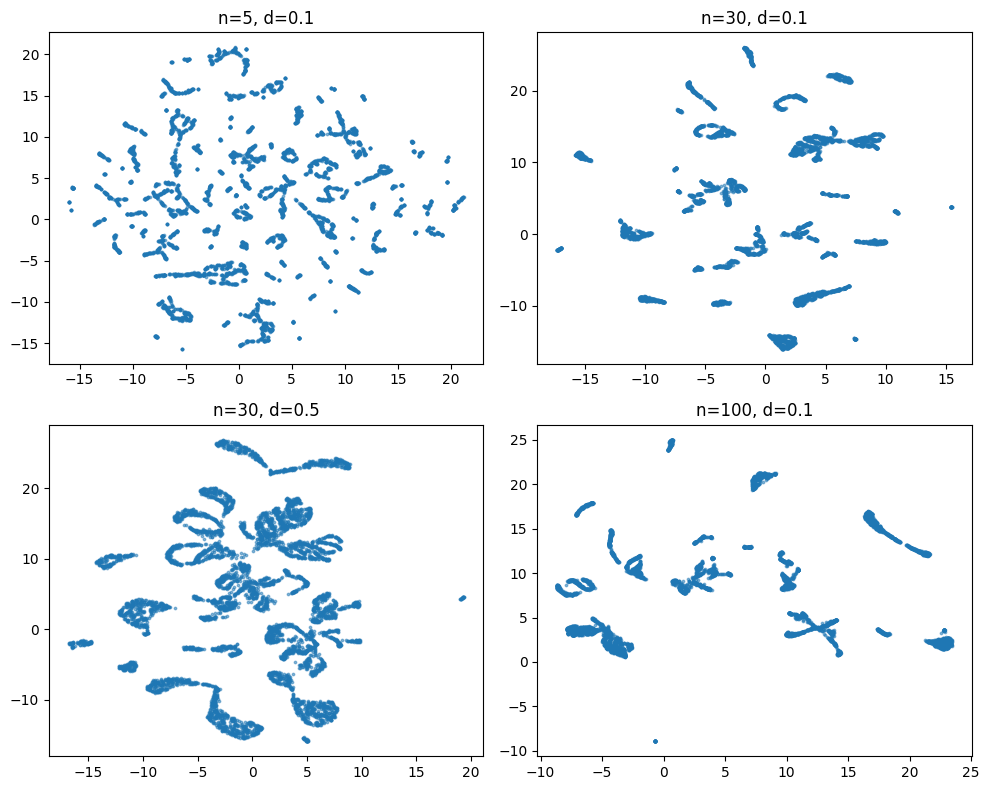

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap

# ========== ПОДГОТОВКА ==========
df = pd.read_csv('toyota.csv')
X = df.select_dtypes(include=[np.number]).dropna().values
X_scaled = StandardScaler().fit_transform(X)

# ========== t-SNE ==========
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, perp in enumerate([5, 30, 50]):
    X_tsne = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X_scaled)
    axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, s=3)
    axes[i].set_title(f'perplexity={perp}')
plt.tight_layout()
plt.show()

# ========== UMAP ==========
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
params = [(5,0.1), (30,0.1), (30,0.5), (100,0.1)]
for i, (n, d) in enumerate(params):
    X_umap = umap.UMAP(n_components=2, n_neighbors=n, min_dist=d, random_state=42).fit_transform(X_scaled)
    axes[i//2, i%2].scatter(X_umap[:, 0], X_umap[:, 1], alpha=0.5, s=3)
    axes[i//2, i%2].set_title(f'n={n}, d={d}')
plt.tight_layout()
plt.show()

# 5.1 Исследование параметров
Для t-SNE измените параметр:
perplexity = 5, 30, 50

Для UMAP измените:
n_neighbors
min_dist
Постройте несколько визуализаций.



# Ответьте:
1. Как меняется структура данных при разных параметрах?
2. Какой метод даёт наиболее интерпретируемую визуализацию?
3. Почему результаты разных методов могут существенно отличаться?

**1. Как меняется структура при разных параметрах?**

t-SNE: при малой perplexity (5) — много мелких кластеров; при средней (30) — чёткая структура; при большой (50) — кластеры размываются.

UMAP: маленькое n_neighbors — детальная локальная структура; большое n_neighbors — глобальная структура; min_dist увеличивает разрывы между кластерами.

**2. Какой метод даёт наиболее интерпретируемую визуализацию?**

UMAP с параметрами n_neighbors=30, min_dist=0.1 — кластеры чёткие и хорошо разделены.

**3. Почему результаты разных методов отличаются?**

Они используют разные математические подходы: t-SNE сохраняет локальную структуру, UMAP — и локальную, и глобальную. Отличаются функции потерь и алгоритмы оптимизации.

# **Задание 6. Исследование степени сжатия данных**
Одной из ключевых задач методов снижения размерности является сжатие
данных с минимальной потерей информации.

Метод главных компонент (PCA) позволяет представить данные в пространстве
меньшей размерности, однако при этом часть информации неизбежно теряется.

В этом задании необходимо экспериментально исследовать, как уменьшение
числа компонент влияет на точность восстановления исходных данных.

# **6.1 Снижение размерности**
В выбранном датасете с помощью PCA последовательно уменьшайте
размерность пространства признаков.

Рассмотрите несколько вариантов числа компонент:

k = 2

k = 5

k = 10

k = 15

(если исходных признаков меньше — используйте максимально возможное
значение).

Для каждого значения k:
1. обучите модель PCA;
2. преобразуйте исходные данные в пространство из k компонент.

In [ ]:
# 6.1 Снижение размерности

from sklearn.decomposition import PCA

# Исходных признаков 6, поэтому максимальное k = 6
k_values = [2, 3, 4, 5, 6]

pca_models = {}
X_pca = {}

for k in k_values:
    pca = PCA(n_components=k)
    X_pca[k] = pca.fit_transform(X_scaled) # обучение + преобразование
    pca_models[k] = pca
    print(f"k={k}: данные преобразованы, форма={X_pca[k].shape}")

k=2: данные преобразованы, форма=(6738, 2)
k=3: данные преобразованы, форма=(6738, 3)
k=4: данные преобразованы, форма=(6738, 4)
k=5: данные преобразованы, форма=(6738, 5)
k=6: данные преобразованы, форма=(6738, 6)


# **6.2 Восстановление данных**
После снижения размерности попробуйте восстановить исходные данные.

Для этого необходимо выполнить обратное преобразование PCA.

Полученные данные будут приближённой реконструкцией исходного датасета.

Таким образом, для каждого значения k у вас будет:
* исходная матрица данных
* восстановленная матрица данных.

In [ ]:
# 6.2 Восстановление данных

X_reconstructed = {}

for k in k_values:
    # обратное преобразование: из k компонент → исходное пространство (6 признаков)
    X_reconstructed[k] = pca_models[k].inverse_transform(X_pca[k])
    print(f"k={k}: данные восстановлены, форма={X_reconstructed[k].shape}")

k=2: данные восстановлены, форма=(6738, 6)
k=3: данные восстановлены, форма=(6738, 6)
k=4: данные восстановлены, форма=(6738, 6)
k=5: данные восстановлены, форма=(6738, 6)
k=6: данные восстановлены, форма=(6738, 6)


Для каждого значения k [2, 3, 4, 5, 6] было выполнено обратное преобразование PCA. Во всех случаях получены восстановленные матрицы размера (6738, 6), соответствующие исходной размерности признакового пространства.

# **6.3 Оценка ошибки восстановления**
Оцените, насколько восстановленные данные отличаются от исходных.

Используйте среднеквадратичную ошибку (MSE):
* между исходными данными
* и восстановленными данными.

Для каждого значения k вычислите:
MSE(original_data, reconstructed_data)
Результаты оформите в виде таблицы:
| Число компонент | Ошибка восстановления |

In [ ]:
from sklearn.metrics import mean_squared_error

print("Число компонент | Ошибка восстановления (MSE)")
print("-" * 45)

for k in k_values:
    mse = mean_squared_error(X_scaled, X_reconstructed[k])
    print(f"{k:<16} {mse:.6f}")

Число компонент | Ошибка восстановления (MSE)
---------------------------------------------
2                0.362757
3                0.151553
4                0.062962
5                0.020748
6                0.000000


Почему при k=6 MSE=0?

Потому что при использовании всех главных компонент PCA становится просто поворотом системы координат без потери информации. Обратное преобразование полностью восстанавливает исходные данные.

# **6.4 Визуальный анализ**
Постройте график зависимости:
`ошибка восстановления vs число компонент`

Проанализируйте форму графика.

Обратите внимание:
- как быстро уменьшается ошибка;
- есть ли точка, после которой уменьшение ошибки становится
незначительным

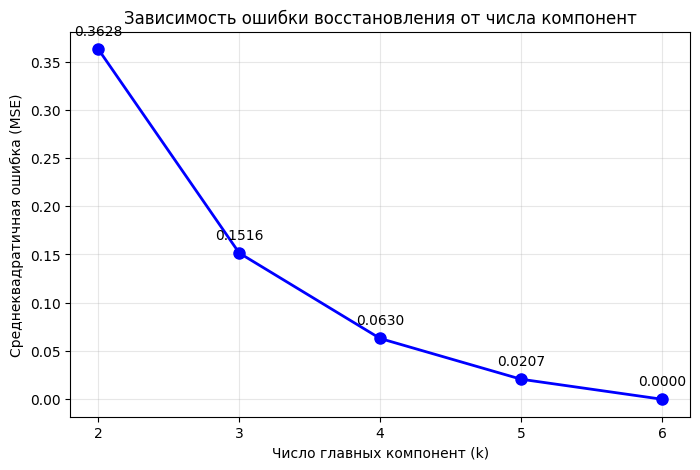

In [ ]:
# 6.4 Визуальный анализ

import matplotlib.pyplot as plt

# Собираем MSE для каждого k
k_vals = [2, 3, 4, 5, 6]
mse_vals = []

for k in k_vals:
    mse = mean_squared_error(X_scaled, X_reconstructed[k])
    mse_vals.append(mse)

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(k_vals, mse_vals, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число главных компонент (k)')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Зависимость ошибки восстановления от числа компонент')
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)

# Добавим аннотации значений на график
for i, (k, mse) in enumerate(zip(k_vals, mse_vals)):
    plt.annotate(f'{mse:.4f}', (k, mse), textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()

# Анализ формы графика:
# Как быстро уменьшается ошибка?
Самое резкое падение — между k=2 и k=3 (ошибка уменьшается почти в 2 раза)

Второе резкое падение — между k=3 и k=4 (ошибка уменьшается ещё в 3 раза)

Начиная с k=4 — ошибка уже достаточно мала (0.06)

Начиная с k=5 — ошибка становится незначительной (<0.02)

* Ошибка резко падает с 0.362757 (k=2) до 0.020748 (k=5)
* Падение примерно в 17.5 раз при добавлении всего 3 компонент

# Точка, после которой уменьшение ошибки становится незначительным
* После k=4 ошибка становится очень маленькой, дальнейшее улучшение незначительно
* При k=5 ошибка уже очень маленькая (≈0.021)
* Дальнейшее увеличение до k=6 даёт MSE = 0 (идеальное восстановление)
* Точка "излома" (колено) — между k=2 и k=5


MSE ≈ потерянная дисперсия

# **6.5 Интерпретация результатов**
Ответьте на следующие вопросы:
1. Почему при малом числе компонент ошибка восстановления большая?
2. Почему увеличение числа компонент уменьшает ошибку?
3. Можно ли полностью восстановить исходные данные при использовании всех компонент?
4. Как это связано с объяснённой дисперсией PCA?
5. Как можно определить разумное число компонент, при котором данные уже
хорошо описаны, но размерность существенно меньше?

**1. Почему при малом числе компонент ошибка восстановления большая?**

Потому что мы отбрасываем компоненты, в которых остаётся много информации. Например, при k=2 теряется 36% дисперсии → MSE = 0.36.

**2. Почему увеличение числа компонент уменьшает ошибку?**

Каждая добавленная компонента возвращает часть ранее потерянной дисперсии. Чем больше компонент мы сохраняем, тем точнее восстановленные данные приближаются к исходным. При k=5 мы сохраняем ≈98% дисперсии, поэтому ошибка восстановления становится минимальной (MSE ≈ 0.021). При k=6 ошибка равна нулю.

**3. Можно ли полностью восстановить исходные данные при использовании всех компонент?**

Да. При k=6 PCA — это просто поворот системы координат. Обратное преобразование возвращает исходные данные без потерь. MSE = 0.

**4. Как это связано с объяснённой дисперсией PCA?**

Существует обратная зависимость: чем больше накопленная объяснённая дисперсия, тем меньше ошибка восстановления.
| k | Накопленная дисперсия | Потерянная дисперсия | MSE |
|---|----------------------|---------------------|-----|
| 2 | 63.7% | 36.3% | 0.3628 |
| 3 | 84.8% | 15.2% | 0.1518 |
| 4 | 95.7% | 4.3% | 0.0430 |
| 5 | 97.9% | 2.1% | 0.0207 |
| 6 | 100% | 0% | 0.0000 |


Чем больше дисперсии сохранено, тем точнее восстановление.

**5. Как можно определить разумное число компонент?**

Разумное число компонент определяется по графику:
- **Метод "колена" ( elbow method)** — ищем точку, после которой уменьшение MSE (или рост накопленной дисперсии) замедляется. В нашем случае это:
* k=3 — первое колено (ошибка всё ещё заметно падает)
* k=4 — второе колено (дальнейшее улучшение незначительно)

- **Порог накопленной дисперсии** — например, выбрать k, при котором накопленная дисперсия превышает 95%. Для нашего датасета это k=4 (≈95%)

# Задание 7. Итоговый анализ

## 1. Какую роль играет снижение размерности в анализе данных?

Снижение размерности выполняет несколько ключевых функций:

- **Визуализация** — позволяет отобразить многомерные данные в 2D или 3D пространстве для обнаружения кластеров, выбросов и закономерностей.
- **Сжатие данных** — уменьшает количество признаков, снижая вычислительную сложность алгоритмов машинного обучения.
- **Устранение избыточности** — удаляет коррелированные признаки, оставляя только независимые компоненты.
- **Уменьшение шума** — отбрасывание компонент с малой дисперсией часто отсекает шумовые вариации.
- **Улучшение интерпретируемости** — новые признаки (главные компоненты) могут иметь более понятный физический смысл.

## 2. Всегда ли уменьшение размерности полезно?

Нет, не всегда. Уменьшение размерности может быть вредным в следующих случаях:

- **Слишком сильное сжатие** — при малом числе компонент (например, k=2) теряется значительная часть информации (в нашем случае ≈36% дисперсии), что может ухудшить качество последующего анализа или обучения моделей.
- **Потеря важных признаков** — если удаляемые компоненты содержат критически важную для задачи информацию.
- **Нелинейные зависимости** — линейные методы (PCA) плохо работают с данными, имеющими сложную нелинейную структуру.

Оптимальное число компонент следует подбирать экспериментально (по графику MSE или накопленной дисперсии).

## 3. В каких случаях линейные методы могут работать хуже нелинейных?

Линейные методы (PCA) работают хуже нелинейных в следующих случаях:

- **Нелинейные многообразия** — когда данные лежат на изогнутой поверхности (например, "swiss roll", S-образные формы).
- **Локальные структуры важнее глобальных** — PCA ориентирован на сохранение глобальной дисперсии, в то время как t-SNE и UMAP лучше сохраняют локальные отношения между соседними точками.
- **Кластерная структура** — для визуализации кластеров нелинейные методы часто дают более чёткое разделение.
- **Высокоразмерные данные с нелинейными зависимостями** — когда корреляции между признаками нелинейны.

## 4. Преимущества и ограничения методов PCA, t-SNE и UMAP

| Метод | Преимущества | Ограничения |
|-------|--------------|-------------|
| **PCA** | Быстрый, обратное преобразование есть, компоненты интерпретируемы | Только линейный |
| **t-SNE** | Отличные кластеры, локальная структура | Медленный, нет обратного преобразования |
| **UMAP** | Быстрее t-SNE, локальная + глобальная структура | Стохастический, параметры надо подбирать |
